# 07  -  Ensemble & Experimental Evaluation
5 experiments from the thesis + stacking ensemble.

**Inputs:** `outputs/*_features.csv`, `outputs/baseline_results.csv`, `outputs/domain_adaptation_results.csv`  
**Outputs:** `outputs/all_experiment_results.csv`, `models/stack_*.pkl`

In [1]:
exec(open('00_config.py').read())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import (f1_score, roc_auc_score, precision_score, recall_score,
                              matthews_corrcoef, precision_recall_curve, auc)
from scipy import stats
import xgboost as xgb
from imblearn.over_sampling import SMOTE

cc = pd.read_csv(CC_FEATURES_CSV)
mm = pd.read_csv(MM_FEATURES_CSV)
hi = pd.read_csv(HI_FEATURES_CSV)
baseline_results = pd.read_csv(os.path.join(OUTPUT_DIR, 'baseline_results.csv'))
da_results       = pd.read_csv(os.path.join(OUTPUT_DIR, 'domain_adaptation_results.csv'))
print('Loaded')

Config loaded. BASE_DIR: /home/compute.ashesi.lan/sedem.agudetse/UniFraud-GH
Loaded


## Helpers

In [2]:
def get_metrics(y_true, y_pred, y_prob=None):
    m = {
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'mcc':       matthews_corrcoef(y_true, y_pred),
    }
    if y_prob is not None:
        try:
            m['roc_auc'] = roc_auc_score(y_true, y_prob)
            prec, rec, _ = precision_recall_curve(y_true, y_prob)
            m['pr_auc']  = auc(rec, prec)
        except Exception:
            m['roc_auc'] = m['pr_auc'] = 0.0
    return m

def split_data(df):
    X = df.drop(columns=[TARGET_COL]).select_dtypes(include=np.number).fillna(0)
    y = df[TARGET_COL]
    X_tv, X_test, y_tv, y_test = train_test_split(X, y, test_size=TEST_RATIO, stratify=y, random_state=RANDOM_STATE)
    val_rel = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
    X_tr, X_val, y_tr, y_val = train_test_split(X_tv, y_tv, test_size=val_rel, stratify=y_tv, random_state=RANDOM_STATE)
    return X_tr, X_val, X_test, y_tr, y_val, y_test

def remove_hi_leaks(X_tr, X_val, X_test, name):
    if name != 'Health Insurance':
        return X_tr, X_val, X_test
    leak_kw = ['dev_','overbill','billing_variab','drg_fraud_rate','max_deviation',
               'multi_field','is_overbill','amount_deviation','amount_zscore',
               'is_large_trans','is_micro_trans','is_high_value','is_service_dom']
    exact   = ['Total','Service','Medical','Approved_Cost','service_to_total_ratio','NHIS ID No','Folder No']
    drop = list(dict.fromkeys(
        [c for c in X_tr.columns if any(k in c.lower() for k in leak_kw)] +
        [c for c in X_tr.columns if c in exact]
    ))
    X_tr  = X_tr.drop(columns=drop)
    X_val = X_val.drop(columns=drop)
    X_test = X_test.drop(columns=drop)
    return X_tr, X_val, X_test

def smart_threshold(probs, y_true):
    use_mcc = y_true.mean() < 0.05
    best_t, best_s = 0.5, -999
    for t in np.arange(0.01, 0.99, 0.005):
        preds = (probs >= t).astype(int)
        if preds.sum() == 0 or preds.sum() == len(preds): continue
        s = matthews_corrcoef(y_true, preds) if use_mcc else f1_score(y_true, preds, zero_division=0)
        if s > best_s: best_s, best_t = s, t
    return best_t

domain_data = {'Credit Card': cc, 'Mobile Money': mm, 'Health Insurance': hi}

# Semantic projection (shared with NB06)  -  maps domain features to 3 universal concepts
SEMANTIC_GROUPS = {
    'Credit Card':      {'amount_anomaly':['amount_zscore','amount_deviation','is_large','is_micro','amt_ghs','is_high_value','amount_is_round','amt'],
                         'counterparty_risk':['category','merchant','high_risk_cat','high_risk_merch'],
                         'structural_distance':['geo_distance','long_distance','is_rural','unusual_timing','tx_burst','rapid_succession']},
    'Mobile Money':     {'amount_anomaly':['amount_zscore','amount_deviation','is_large','is_micro','is_high_value','amount'],
                         'counterparty_risk':['recipient','oldBal','newBal','balance_zeroed','is_agent'],
                         'structural_distance':['balance_error','unusual_timing','tx_burst','rapid_succession']},
    'Health Insurance': {'amount_anomaly':['amount_zscore','amount_deviation','is_large','is_micro','dev_total','dev_service','dev_medical','max_deviation'],
                         'counterparty_risk':['drg_fraud_rate','drg_claim','drg_billing','drg_cluster'],
                         'structural_distance':['overbill','multi_field','billing_variab','unusual_timing','tx_burst','rapid_succession']},
}

def semantic_project(X, feature_names, domain):
    result = np.zeros((X.shape[0], 3), dtype=np.float32)
    for idx, concept in enumerate(['amount_anomaly','counterparty_risk','structural_distance']):
        kws     = SEMANTIC_GROUPS.get(domain, {}).get(concept, [])
        matched = [i for i, n in enumerate(feature_names) if any(k.lower() in n.lower() for k in kws)]
        if matched:
            g = X[:, matched]
            g = (g - g.mean(0)) / (g.std(0) + 1e-8)
            result[:, idx] = g.mean(1)
    return result

print('Helpers defined')

Helpers defined


## Exp 1  -  Within-Domain Baseline

In [3]:
print('='*60)
print('EXPERIMENT 1: Within-Domain Baseline')
print('='*60)
exp1 = baseline_results.copy()
exp1['experiment'] = 'Exp1_Within_Domain'
for domain in ['Credit Card','Mobile Money','Health Insurance']:
    sub  = exp1[exp1['domain'] == domain]
    best = sub.loc[sub['f1'].idxmax()]
    print(f'  {domain}: best={best["model"]} F1={best["f1"]:.4f} AUC={best.get("roc_auc",0):.4f}')

EXPERIMENT 1: Within-Domain Baseline
  Credit Card: best=Random Forest F1=0.4270 AUC=0.9652
  Mobile Money: best=XGBoost F1=0.9967 AUC=0.9999
  Health Insurance: best=XGBoost F1=0.8571 AUC=0.9483


## Exp 2  -  Direct Cross-Domain Transfer

In [4]:
print('='*60)
print('EXPERIMENT 2: Direct Cross-Domain Transfer')
print('='*60)

scenarios = [
    ('Credit Card','Mobile Money'), ('Credit Card','Health Insurance'),
    ('Mobile Money','Credit Card'), ('Mobile Money','Health Insurance'),
    ('Health Insurance','Credit Card'), ('Health Insurance','Mobile Money'),
]

exp2_results = []
for src_name, tgt_name in scenarios:
    src_df, tgt_df = domain_data[src_name], domain_data[tgt_name]
    src_X = src_df.drop(columns=[TARGET_COL]).select_dtypes(include=np.number).fillna(0)
    tgt_X = tgt_df.drop(columns=[TARGET_COL]).select_dtypes(include=np.number).fillna(0)
    sfn = [c for c in src_df.columns if c != TARGET_COL]
    tfn = [c for c in tgt_df.columns if c != TARGET_COL]

    # Project into 3-dimensional concept space before transferring
    src_c = pd.DataFrame(semantic_project(src_X.values.astype(np.float32), sfn, src_name),
                         columns=['amount_anomaly','counterparty_risk','structural_distance'])
    tgt_c = pd.DataFrame(semantic_project(tgt_X.values.astype(np.float32), tfn, tgt_name),
                         columns=['amount_anomaly','counterparty_risk','structural_distance'])

    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(src_c, src_df[TARGET_COL])
    y_pred = rf.predict(tgt_c)
    y_prob = rf.predict_proba(tgt_c)[:, 1]

    m = get_metrics(tgt_df[TARGET_COL], y_pred, y_prob)
    m.update({'experiment':'Exp2_Direct_Transfer','source':src_name,'target':tgt_name,'model':'RF_Direct'})
    exp2_results.append(m)
    print(f'  {src_name[:3]}->{tgt_name[:3]}: F1={m["f1"]:.4f} AUC={m.get("roc_auc",0):.4f}')

exp2_df = pd.DataFrame(exp2_results)
print(f'\nMean F1 (direct transfer): {exp2_df["f1"].mean():.4f}')

EXPERIMENT 2: Direct Cross-Domain Transfer
  Cre->Mob: F1=0.0000 AUC=0.0499
  Cre->Hea: F1=0.0000 AUC=0.4997
  Mob->Cre: F1=0.0119 AUC=0.6650
  Mob->Hea: F1=0.3305 AUC=0.3800
  Hea->Cre: F1=0.0062 AUC=0.4811
  Hea->Mob: F1=0.6417 AUC=0.6376

Mean F1 (direct transfer): 0.1651


## Exp 3  -  Domain Adaptation (from NB06)

In [5]:
print('='*60)
print('EXPERIMENT 3: Domain Adaptation')
print('='*60)
exp3 = da_results.copy()
exp3['experiment'] = 'Exp3_Domain_Adaptation'

print(exp3.groupby('method')[['f1','mcc','roc_auc']].mean().round(4))
for method in exp3['method'].unique():
    mean_f1   = exp3[exp3['method'] == method]['f1'].mean()
    direct_f1 = exp2_df['f1'].mean()
    print(f'  {method}: {mean_f1:.4f}  (delta_ vs direct: {mean_f1 - direct_f1:+.4f})')

EXPERIMENT 3: Domain Adaptation
                          f1     mcc  roc_auc
method                                       
DANN                  0.5894  0.4819   0.8367
HEN                   0.7186  0.7061   0.9347
Subdomain Adaptation  0.6434  0.5332   0.8352
  DANN: 0.5894  (delta_ vs direct: +0.4243)
  Subdomain Adaptation: 0.6434  (delta_ vs direct: +0.4783)
  HEN: 0.7186  (delta_ vs direct: +0.5535)


## Exp 4  -  Universal Features

In [6]:
from sklearn.inspection import permutation_importance

print('='*60)
print('EXPERIMENT 4: Universal Feature Identification')
print('='*60)

fi_by_domain = {}
for name, df in domain_data.items():
    X = df.drop(columns=[TARGET_COL]).select_dtypes(include=np.number).fillna(0)
    y = df[TARGET_COL]
    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X, y)
    fi_by_domain[name] = pd.Series(rf.feature_importances_, index=X.columns)
    print(f'\n{name}  -  Top 5:')
    for feat, imp in fi_by_domain[name].nlargest(5).items():
        print(f'  {feat:<40} {imp:.4f}')

# Universal feature groups (same names engineered by add_universal_features in NB03)
UNIVERSAL = {
    'Amount anomaly':   ['amount_zscore','amount_deviation_pct','is_large_transaction','is_micro_transaction'],
    'Velocity / timing':['rapid_succession','tx_burst_flag','time_since_prev','unusual_timing'],
}
print('\n--- Conceptual universal features: presence & rank per domain ---')
for group, feats in UNIVERSAL.items():
    print(f'[{group}]')
    for feat in feats:
        for domain, imps in fi_by_domain.items():
            if feat in imps.index:
                rank = int(imps.rank(ascending=False)[feat])
                print(f'  {feat:<35} {domain[:15]:<15} rank={rank:>3}  imp={imps[feat]:.4f}')

EXPERIMENT 4: Universal Feature Identification

Credit Card  -  Top 5:
  amt                                      0.3013
  amount_deviation_pct                     0.2986
  is_high_value                            0.0832
  is_large_transaction                     0.0801
  geo_distance                             0.0541

Mobile Money  -  Top 5:
  recipient                                0.5320
  amount                                   0.2230
  oldBalInitiator                          0.0813
  is_large_transaction                     0.0807
  oldBalRecipient                          0.0766

Health Insurance  -  Top 5:
  Folder No                                0.3124
  NHIS ID No                               0.2988
  G-DRG                                    0.1169
  dev_total                                0.0935
  Attendance Date                          0.0259

--- Conceptual universal features: presence & rank per domain ---
[Amount anomaly]
  amount_deviation_pct                Cre

## Exp 5  -  Stacking Ensemble

In [7]:
print('='*60)
print('EXPERIMENT 5: Stacking Ensemble')
print('='*60)

ensemble_results = []
for name, df in domain_data.items():
    print(f'\n  {name}')
    X_tr, X_val, X_test, y_tr, y_val, y_test = split_data(df)
    X_tr, X_val, X_test = remove_hi_leaks(X_tr, X_val, X_test, name)

    minority = int(y_tr.sum())
    current  = minority / (len(y_tr) - minority) if len(y_tr) > minority else 1.0
    target   = min(SMOTE_RATIO, 0.5)
    if minority >= 6 and current < target:
        sm = SMOTE(sampling_strategy=target, random_state=RANDOM_STATE, k_neighbors=min(5, minority-1))
        X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

    estimators = [
        ('rf',  RandomForestClassifier(**RF_PARAMS)),
        ('xgb', xgb.XGBClassifier(**{k:v for k,v in XGB_PARAMS.items() if k != 'use_label_encoder'})),
        ('lr',  LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),
    ]
    stack = StackingClassifier(estimators=estimators,
                               final_estimator=LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
                               cv=CV_FOLDS, stack_method='predict_proba', n_jobs=-1)
    stack.fit(X_tr, y_tr)
    y_prob = stack.predict_proba(X_test)[:, 1]
    thresh = smart_threshold(stack.predict_proba(X_val)[:, 1], y_val)
    y_pred = (y_prob >= thresh).astype(int)

    m = get_metrics(y_test, y_pred, y_prob)
    m.update({'experiment':'Exp5_Ensemble','model':'Stacking','domain':name})
    ensemble_results.append(m)

    primary   = 'roc_auc' if name == 'Credit Card' else 'mcc'
    best_base = baseline_results[baseline_results['domain'] == name][primary].max()
    print(f'  {primary}={m[primary]:.4f}  baseline={best_base:.4f}  delta_={m[primary]-best_base:+.4f}')
    joblib.dump(stack, os.path.join(MODEL_DIR, f'stack_{name.replace(" ","_").lower()}.pkl'))

ens_df = pd.DataFrame(ensemble_results)
print('\nEnsemble complete')

EXPERIMENT 5: Stacking Ensemble

  Credit Card
  roc_auc=0.9556  baseline=0.9660  delta_=-0.0104

  Mobile Money
  mcc=0.9928  baseline=0.9928  delta_=-0.0000

  Health Insurance
  mcc=0.8402  baseline=0.7485  delta_=+0.0917

Ensemble complete


## Statistical Validation

In [14]:
print('\nStatistical Validation  -  Paired t-tests (alpha=0.05)')

domain_cv = {}
for _, row in ens_df.iterrows():
    domain = row['domain']
    df_    = domain_data[domain]
    X = df_.drop(columns=[TARGET_COL]).select_dtypes(include=np.number).fillna(0)
    y = df_[TARGET_COL]
    cv  = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    f1s = cross_val_score(RandomForestClassifier(**RF_PARAMS), X, y, cv=cv, scoring='f1', n_jobs=-1)
    ci  = np.percentile(f1s, [2.5, 97.5])
    domain_cv[domain] = f1s
    print(f'  {domain}: F1={f1s.mean():.4f} +/- {f1s.std():.4f}  95%CI=[{ci[0]:.4f},{ci[1]:.4f}]')

print('\nEnsemble vs XGBoost baseline:')
for domain, ens_scores in domain_cv.items():
    df_ = domain_data[domain]
    X   = df_.drop(columns=[TARGET_COL]).select_dtypes(include=np.number).fillna(0)
    y   = df_[TARGET_COL]
    cv  = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    xgb_params_cv = {k: v for k, v in XGB_PARAMS.items() if k not in ('use_label_encoder', 'eval_metric')}
    base_scores = cross_val_score(
        xgb.XGBClassifier(**xgb_params_cv),
        X, y, cv=cv, scoring='f1', n_jobs=-1
    )
    t, p = stats.ttest_rel(ens_scores, base_scores)
    print(f'  {domain}: t={t:.3f}  p={p:.4f}  {"significant" if p<0.05 else "not significant"}')

da_df = da_results
dann = da_df[da_df['method']=='DANN']['f1'].values
hen  = da_df[da_df['method']=='HEN']['f1'].values
sub  = da_df[da_df['method']=='Subdomain Adaptation']['f1'].values
if len(dann) == len(hen):
    t1, p1 = stats.ttest_rel(hen, dann)
    t2, p2 = stats.ttest_rel(hen, sub)
    print(f'\n  HEN vs DANN:      t={t1:.3f}  p={p1:.4f}  {"significant" if p1<0.05 else "not significant"}')
    print(f'  HEN vs Subdomain: t={t2:.3f}  p={p2:.4f}  {"significant" if p2<0.05 else "not significant"}')


Statistical Validation  -  Paired t-tests (alpha=0.05)
  Credit Card: F1=0.0940 +/- 0.0037  95%CI=[0.0908,0.1003]
  Mobile Money: F1=0.9962 +/- 0.0001  95%CI=[0.9961,0.9963]
  Health Insurance: F1=0.9964 +/- 0.0018  95%CI=[0.9955,0.9995]

Ensemble vs XGBoost baseline:
  Credit Card: t=0.160  p=0.8805  not significant
  Mobile Money: t=-8.545  p=0.0010  significant
  Health Insurance: t=1.010  p=0.3697  not significant

  HEN vs DANN:      t=1.763  p=0.1382  not significant
  HEN vs Subdomain: t=1.700  p=0.1499  not significant


## Save All Results

Saved -> /home/compute.ashesi.lan/sedem.agudetse/UniFraud-GH/outputs/all_experiment_results.csv


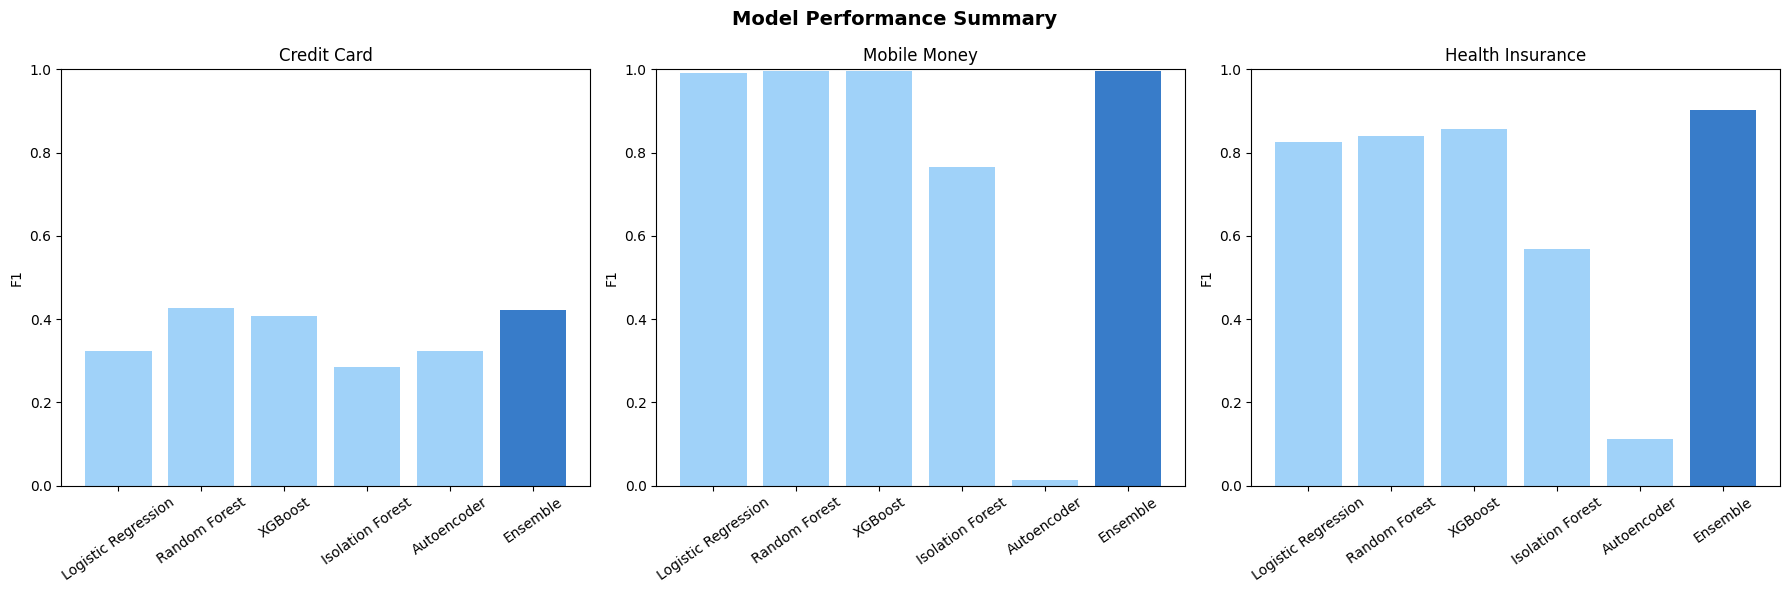

In [15]:
all_results = pd.concat([
    exp1.assign(experiment='Exp1'),
    exp2_df.assign(model='RF_Direct'),
    exp3.rename(columns={'source':'src','target':'tgt'}),
    ens_df.assign(experiment='Exp5'),
], ignore_index=True)

all_results.to_csv(os.path.join(OUTPUT_DIR, 'all_experiment_results.csv'), index=False)
print(f'Saved -> {OUTPUT_DIR}/all_experiment_results.csv')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, domain in zip(axes, ['Credit Card','Mobile Money','Health Insurance']):
    base = baseline_results[baseline_results['domain'] == domain]
    ens  = ens_df[ens_df['domain'] == domain]
    models = base['model'].tolist() + ['Ensemble']
    f1s    = base['f1'].tolist() + ens['f1'].tolist()
    colors = ['#90CAF9'] * len(base) + ['#1565C0']
    ax.bar(models, f1s, color=colors, alpha=0.85)
    ax.set_ylim(0, 1); ax.set_title(domain)
    ax.set_ylabel('F1'); ax.tick_params(axis='x', rotation=35)

plt.suptitle('Model Performance Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '07_experiment_summary.png'), dpi=150, bbox_inches='tight')
plt.show()